In [1]:
#!/usr/bin/env python
from scipy.stats import expon
from scipy.stats import uniform
from scipy.stats import norm
from scipy.stats import multivariate_normal
from numpy.random import multinomial
from numpy.random import uniform
import numpy as np
import matplotlib.pyplot as plt
import scipy 
from scipy.stats import truncnorm
import math
from scipy.stats import mvn
np.set_printoptions(suppress=True)
import pyreadr
import time
import sys
from math import comb
from numpy.linalg import LinAlgError
import random
from scipy.linalg import cho_solve, cho_factor
import math
from math import lgamma, exp
from scipy.special import comb 
from scipy.stats import mvn
from statsmodels.sandbox.distributions.extras import mvstdnormcdf
np.random.seed(123)


data = pyreadr.read_r('archive/cell_lineage/UGPMA100new.rda')
points_inhomo = np.array(data["bt_adj"]).squeeze()
T=25




ntip=100
N = ntip - 1
Ngrid = 100
K= ntip  # counts of integrals
x4 = np.linspace(0, T, Ngrid + 1)[1:]
xxx=np.concatenate([x4, points_inhomo])

days = np.concatenate([[0], points_inhomo,[T]])
diff = np.diff(days)
Nfinal = Ngrid + N + K
g_mk = 3 + np.zeros(Nfinal)
g_mk[ Ngrid+N:Ngrid+N+K ]=3*T*diff/sum(diff)


nsim1 = 10000
nsim2 = 10000

def inten2(t):
    return 25*np.exp(-5*t)

# -------------------------- kernels ------------------------------------------
def expo_quad_kernel(theta1, xn, xm):
    return np.exp(-theta1/2*np.sum((xn - xm)**2))

def expo_quad_kernel2(theta1, xn, t1, t2):
    rt = np.sqrt(theta1/2)
    return np.sqrt(np.pi/2/theta1)*(math.erf(rt*(t2-xn)) - math.erf(rt*(t1-xn)))

def expo_quad_kernel3(theta1, t1, t2, t3, t4):
    rt = np.sqrt(theta1/2)
    term = (t2-t3)*math.erf(rt*(t2-t3)) - (t2-t4)*math.erf(rt*(t2-t4)) \
         - (t1-t3)*math.erf(rt*(t1-t3)) + (t1-t4)*math.erf(rt*(t1-t4))
    exp_part = np.exp(-theta1/2*(t2-t3)**2) - np.exp(-theta1/2*(t1-t3)**2) \
             - np.exp(-theta1/2*(t2-t4)**2) + np.exp(-theta1/2*(t1-t4)**2)
    return np.sqrt(np.pi/2/theta1)*term + (1/theta1)*exp_part



def a_coeffs_kmax(kmax):
    if kmax == 1 or kmax == 2:
        return np.array([1.0])

    a_prev = np.array([1.0])  # k = 2

    for k in range(3, kmax + 1):
        Mk = comb(k - 1, 2)
        Mk_prev = comb(k - 2, 2)

        a_cur = np.zeros(int(Mk) + 1, dtype=float)

        for i in range(0, int(Mk) + 1):
            if i == 0:
                a_cur[i] = 1.0
                continue

            a_im1_k = a_cur[i - 1]

            if i <= Mk_prev:
                a_i_km1 = a_prev[i]
            else:
                a_i_km1 = 0.0

            numerator = (
                (comb(k - 1, 2) - i + 1) * a_im1_k
                + comb(k, 2) * a_i_km1
            )

            denominator = comb(k, 2) - i
            a_cur[i] = numerator / denominator

        a_prev = a_cur

    return a_prev


a = a_coeffs_kmax(ntip)


def rhs_value(x, a=a):
    poly = 0.0

    for coeff in reversed(a):
        poly = poly * x + coeff

    return poly


n_vec = np.arange(ntip, 1, -1)
com_vec = n_vec * (n_vec - 1) / 2


# -------------------------- sampling utils -----------------------------------
def chol_sample(mean, cov_chol):
    return mean + cov_chol @ np.random.standard_normal(mean.size)

def log_lik(f, ns):
    if np.any(f <= 0):
        return -np.inf

    term1 = np.sum(np.log(f[:, Ngrid:Ngrid+ns]))
    term2 = -np.sum(com_vec * f[:, Ngrid+ns:Nfinal-1])

    Lambda = np.sum(f[:, Ngrid+ns:Nfinal])
    x = np.exp(-Lambda)
    val = rhs_value(x)

    # Stable evaluation of log(1 - exp(-Lambda)).
    # Directly forming 1 - exp(-Lambda) loses precision when Lambda is small.
    log_one_minus_x = np.log(-np.expm1(-Lambda))
    logboundprob = (ntip - 1) * log_one_minus_x + np.log(val)
    term3 = -logboundprob

    return term1 + term2 + term3

def elliptical_slice(initial_theta, prior, lnpdf, pdf_params=(),
                     cur_lnpdf=None, angle_range=None):
    D = len(initial_theta)
    if cur_lnpdf is None:
        cur_lnpdf = lnpdf(initial_theta, *pdf_params)

    if len(prior.shape) == 1:
        nu = prior
    else:
        if not (prior.shape[0] == D and prior.shape[1] == D):
            raise IOError("Prior must be a D-element sample or DxD chol(Sigma)")
        nu = prior @ np.random.normal(size=D)

    hh = math.log(np.random.uniform()) + cur_lnpdf

    if angle_range is None or angle_range == 0.:
        phi = np.random.uniform()*2.*math.pi
        phi_min = phi - 2.*math.pi
        phi_max = phi
    else:
        phi_min = -angle_range*np.random.uniform()
        phi_max = phi_min + angle_range
        phi = np.random.uniform()*(phi_max - phi_min) + phi_min

    while True:
        xx_prop = initial_theta*math.cos(phi) + nu*math.sin(phi)
        cur_lnpdf = lnpdf(xx_prop, *pdf_params)
        if cur_lnpdf > hh:
            break
        if phi > 0:
            phi_max = phi
        elif phi < 0:
            phi_min = phi
        else:
            raise RuntimeError('BUG DETECTED: Shrunk to current position and still not acceptable.')
        phi = np.random.uniform()*(phi_max - phi_min) + phi_min
    return (xx_prop, cur_lnpdf)

# ---------- fast MVN prob using Cholesky only (no full Sigma) ----------------
def mvn_prob_from_chol_fast(lower, upper, mean, L,
                            maxpts=2_000_000, abseps=1e-3, releps=1e-3):
    lower = np.asarray(lower, float).ravel()
    upper = np.asarray(upper, float).ravel()
    mean  = np.asarray(mean,  float).ravel()

    # std devs (sqrt of diag(Sigma)) = row norms of L
    s = np.linalg.norm(L, axis=1)
    s = np.maximum(s, 1e-12)

    lower_z = (lower - mean) / s
    upper_z = (upper - mean) / s

    L_tilde = L / s[:, None]
    R = L_tilde @ L_tilde.T
    R = 0.5 * (R + R.T)

    p = mvstdnormcdf(lower_z, upper_z, R,
                     maxpts=int(maxpts), abseps=abseps, releps=releps)
    return float(max(p, 1e-300))

# ------------------------ build Cholesky (discard K) -------------------------
def build_chol(theta1, jitter):
    """Build kernel K (locally), return only its jittered Cholesky; discard K."""
    K = np.zeros((Nfinal, Nfinal), dtype=np.float64)
    for i in range(Nfinal):
        for j in range(i, Nfinal):
            if j < Ngrid + N and i < Ngrid + N:
                kij = expo_quad_kernel(theta1, xxx[i], xxx[j])
            elif j >= Ngrid + N and i < Ngrid + N:
                kij = expo_quad_kernel2(theta1, xxx[i],
                                        days[j - Ngrid - N], days[j - Ngrid - N + 1])
            else:
                kij = expo_quad_kernel3(theta1,
                                        days[i - Ngrid - N], days[i - Ngrid - N + 1],
                                        days[j - Ngrid - N], days[j - Ngrid - N + 1])
            K[i, j] = kij
            if j != i:
                K[j, i] = kij


    K_stab = K + jitter * np.eye(Nfinal)
    L = np.linalg.cholesky(K_stab)
    return L

# ------------------------ posterior & MH (chol-only) -------------------------
def log_posterior(l, mu_l, scale_l, f, theta0, jitter, cov_K_chol=None,mvn_tol=(2_000_000, 1e-3, 1e-3)):
    theta11 = np.exp(-2*l)

    built = False
    if cov_K_chol is None:
        cov_K_chol = build_chol(theta11, jitter)
        built = True

    theta0_scalar = np.asarray(theta0).item()
    comp2 = -0.5 * theta0_scalar * (f @ cho_solve((cov_K_chol, True), f))
    comp1 = norm.logpdf(l, loc=mu_l, scale=scale_l)

    d = len(f)
    mean = np.zeros(d)
    lower = np.zeros(d)
    upper = np.full(d, np.inf)
    maxpts, abseps, releps = mvn_tol
    
    prob = mvn_prob_from_chol_fast(lower, upper, mean, cov_K_chol,
                                   maxpts=maxpts, abseps=abseps, releps=releps)
    
    comp3 = np.log(prob) + np.sum(np.log(np.diag(cov_K_chol)))
    subtotal=comp1-comp3
    total = subtotal + comp2 
    if built:
        return total,subtotal, cov_K_chol
    return total,subtotal

def metropolis_hastings_update(l_current, proposal_sigma_l, mu_l, scale_l,
                               f, theta0, cov_K_chol_current, 
                               jitter, log_post_current_partial=None,mvn_tol=(2_000_000, 1e-3, 1e-3)):
    if log_post_current_partial is None:
        log_post_current,log_post_current_partial = log_posterior(l_current, mu_l, scale_l, f, theta0,jitter, 
                                         cov_K_chol_current, mvn_tol)
    else:
        log_post_current = log_post_current_partial-0.5 * np.asarray(theta0).item() * (f @ cho_solve((cov_K_chol_current, True), f))
    

    l_prop = l_current + np.random.normal(0, proposal_sigma_l)
    lp_prop,log_post_prop_partial, L_prop = log_posterior(l_prop, mu_l, scale_l, f, theta0,jitter=jitter,
                                                 cov_K_chol=None,  mvn_tol=mvn_tol)

    log_alpha = lp_prop - log_post_current 
   
    if np.log(np.random.uniform()) < log_alpha:
        return l_prop,log_post_prop_partial, L_prop,  True
    else:
        return l_current,log_post_current_partial, cov_K_chol_current, False

# ---------------------------- init & run -------------------------------------
theta1 = np.float64(10.0)
l = np.float64(-np.log(theta1) / 2)
proposal_sigma_l = 0.003
mu_l = l
scale_l = 1e4
jitter = 1e-14
cov_K_chol = build_chol(theta1, jitter)
alpha = 0.1
beta  = 0.1
theta = alpha / beta
rem = 10
g_mk_list2, g_mk_list3, theta_list, theta1_list = [], [], [], []
curloglike = None
partialloglik=None
mvn_tol = (2_000_000, 1e-3, 1e-3)
acc_count=0
start_time = time.time()
for ite in range(nsim1 + nsim2):
    if (ite % 100) == 0:
        print(ite)
    cov_K_chol_final = cov_K_chol / np.sqrt(theta)
    prior = chol_sample(mean=np.zeros(Nfinal), cov_chol=cov_K_chol_final)
    g_mk, curloglike = elliptical_slice(g_mk.reshape(1, -1), prior, log_lik,
                                        pdf_params=[N], cur_lnpdf=curloglike, angle_range=None)
    g_mk_list2.append(1/g_mk[0][0:Ngrid])
    g_mk_list3.append(1/g_mk[0][Ngrid:Ngrid+N])

    if (ite % rem) == 0:
       
        alpha_pos = alpha + Nfinal/2
        u = cho_solve((cov_K_chol, True), g_mk[0])
        beta_pos = beta + 0.5 * (g_mk[0] @ u)
        theta = float(np.random.gamma(alpha_pos, 1/beta_pos))
        theta_list.append(theta)
        l, partialloglik,cov_K_chol,acc = metropolis_hastings_update(
            l, proposal_sigma_l, mu_l, scale_l, g_mk[0], theta,
            cov_K_chol, jitter, partialloglik,mvn_tol)
        theta1 = np.exp(-2*l)
        theta1_list.append(theta1)
        if acc:
            acc_count+=1

timerun = time.time() - start_time
timerun_10000 = timerun / (nsim2 + nsim1) * 10000
acc_rate=acc_count/int((nsim2+nsim1)/rem)
nn = int(nsim1/rem)
low  = np.quantile(np.array(g_mk_list2)[nn:,], 0.025, axis=0)
high = np.quantile(np.array(g_mk_list2)[nn:,], 0.975, axis=0)
med  = np.quantile(np.array(g_mk_list2)[nn:,], 0.5, axis=0)
truth = inten2(x4)
l2_dist1 = sum((np.array(med).squeeze() - truth)**2)
coverage1 = np.sum((truth >= low.squeeze()) * (truth <= high.squeeze())) / len(x4)
width1 = sum(high - low) / Ngrid

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
18

In [9]:
jitter

1e-14

In [15]:
nn = int(nsim1/rem)

# grids
low = np.quantile(np.array(g_mk_list2)[nn:,], 0.025, axis=0)
high = np.quantile(np.array(g_mk_list2)[nn:,], 0.975, axis=0)
med = np.quantile(np.array(g_mk_list2)[nn:,], 0.5, axis=0)

truth = inten2(x4)

l2_dist1 = sum((np.array(med).squeeze() - truth)**2)

coverage1 = np.sum(
    (truth >= low.squeeze()) *
    (truth <= high.squeeze())
) / len(x4)

width1 = sum(high - low) / Ngrid


# ============================================================
# HPD intervals
# ============================================================

samples = np.array(g_mk_list2)[nn:]   # shape: n_samples × Ngrid

def hpd_interval(x, alpha=0.05):
    x = np.sort(x)
    n = len(x)
    k = int(np.floor((1 - alpha) * n))
    widths = x[k:] - x[:n-k]
    j = np.argmin(widths)
    return x[j], x[j+k]


low = np.zeros(samples.shape[1])
high = np.zeros(samples.shape[1])

for j in range(samples.shape[1]):
    low[j], high[j] = hpd_interval(samples[:, j], alpha=0.05)




width1 = sum(high - low) / Ngrid




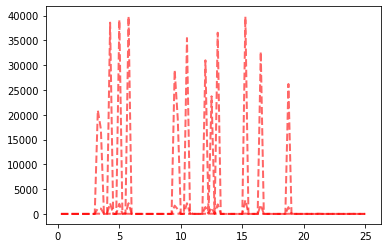

In [16]:
fig, ax = plt.subplots()
#ax.plot(x4,truth,'k-',lw=3,alpha=0.6,label='Truth')
ax.plot(x4,med,'--',lw=2,alpha=0.6,c='r')
ax.plot(x4,low,'--',lw=2,alpha=0.6,c='r',label='SC-RI-BM')
ax.plot(x4,high,'--',lw=2,alpha=0.6,c='r')
